In [43]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [79]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow\\(\\) is deprecated",
    category=DeprecationWarning
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## **Data Collection**

In this project we are using two NASA data sources to study natural disaster events and their surrounding climate conditions.

**NASA EONET (Earth Observatory Natural Event Tracker)** This dataset provides near–real-time information on natural disasters worldwide, including events such as wildfires and severe storms. For each event, EONET records the event title, category, date, geographic coordinates (latitude and longitude) and source information. This dataset forms the core event level data used in the project.

**NASA POWER API (Prediction of Worldwide Energy Resources)**. We are using this dataset to understand the environmental context of each disaster. The POWER API supplies global meteorological variables derived from satellite and reanalysis data. For each EONET event, climate conditions were retrieved using the event’s location and date.

The climate variables used in this project include:

* **Temperature (T2M)** – near-surface air temperature
* **Relative Humidity (RH2M)** – moisture content of the air
* **Wind Speed (WS2M)** – near-surface wind speed
* **Precipitation (PRECTOT)** – total precipitation

By combining NASA EONET disaster records with NASA POWER climate data, a unified dataset was created that links each natural disaster event with localized climate conditions. This integrated dataset supports exploratory analysis and future machine learning tasks throughout the project.

In [45]:
EONET_URL = "https://eonet.gsfc.nasa.gov/api/v3/events"
POWER_URL = "https://power.larc.nasa.gov/api/temporal/daily/point"
params = {"status": "open", "limit": 5000}

response = requests.get(EONET_URL, params=params)
data = response.json()

In [46]:
events = []
for event in data["events"]:
    if event["geometry"]:
        geom = event["geometry"][-1]
        events.append({
            "id": event["id"],
            "title": event["title"],
            "category": event["categories"][0]["title"],
            "date": geom["date"],
            "longitude": geom["coordinates"][0],
            "latitude": geom["coordinates"][1],
            "source": event["sources"][0]["url"]})

df = pd.DataFrame(events)
df.head()

,id,title,category,date,longitude,latitude,source
0,EONET_18309,"TUS Wolfe Ridge RX Prescribed Fire, Clay, Nort...",Wildfires,2026-03-02T12:34:00Z,-83.824950,35.120333,https://irwin.doi.gov/observer/incidents/ff516...
1,EONET_18308,Raven Rock D/Pilgrims Rest A RX Prescribed Fir...,Wildfires,2026-03-02T09:24:00Z,-85.489226,33.818256,https://irwin.doi.gov/observer/incidents/2fc52...
2,EONET_18317,"BSW 05/06 RX Prescribed Fire, Covington, Alabama",Wildfires,2026-03-01T09:14:00Z,-86.576534,31.122318,https://irwin.doi.gov/observer/incidents/ca3fa...
3,EONET_18311,"RX Mount Ida 18 25 29 Prescribed Fire, Montgom...",Wildfires,2026-03-01T09:08:00Z,-93.693889,34.546944,https://irwin.doi.gov/observer/incidents/576b1...
4,EONET_18318,"RX CAT BU 52 Prescribed Fire, Grant, Louisiana",Wildfires,2026-03-01T08:57:00Z,-92.441277,31.623577,https://irwin.doi.gov/observer/incidents/cc0bb...


In [47]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df.isna().sum()

,0
id,0
title,0
category,0
date,0
longitude,0
latitude,0
source,0
year,0
month,0


In [48]:
df = df[(df["latitude"].between(-90, 90)) &
    (df["longitude"].between(-180, 180))]

In [49]:
def get_power_data(lat, lon, date):
    start = (date - timedelta(days=3)).strftime("%Y%m%d")
    end = date.strftime("%Y%m%d")
    params = {
        "parameters": "T2M,RH2M,WS2M,PRECTOT",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON"}

    r = requests.get(POWER_URL, params=params)
    if r.status_code != 200:
        return None

    js = r.json()["properties"]["parameter"]
    return {
        "temp": np.mean(list(js["T2M"].values())),
        "humidity": np.mean(list(js["RH2M"].values())),
        "wind": np.mean(list(js["WS2M"].values())),
        "precip": np.mean(list(js["PRECTOTCORR"].values()))}

In [50]:
sample_df = df.sample(150, random_state=42)

climate_data = []

for _, row in sample_df.iterrows():
    climate = get_power_data(row["latitude"], row["longitude"], row["date"])
    if climate:
        climate_data.append({**row.to_dict(), **climate})

combined_df = pd.DataFrame(climate_data)
combined_df.head()


,id,title,category,date,longitude,latitude,source,year,month,temp,humidity,wind,precip
0,EONET_12845,Wildfire in Colombia 1023557,Wildfires,2025-02-26 19:00:00+00:00,-69.011152,6.056572,https://www.gdacs.org/report.aspx?eventtype=WF...,2025,2,34.1925,41.5950,1.9700,0.0000
1,EONET_11540,"Elkhorn Wildfire, McKenzie, North Dakota",Wildfires,2024-10-06 09:46:00+00:00,-103.206283,47.688967,https://irwin.doi.gov/observer/,2024,10,13.0325,43.9250,4.6550,0.0000
2,EONET_11602,Wildfire in Mozambique 1022618,Wildfires,2024-10-03 19:00:00+00:00,31.921726,-23.285053,https://www.gdacs.org/report.aspx?eventtype=WF...,2024,10,21.3150,52.9850,5.3300,0.0150
3,EONET_13336,Wildfire in Russian Federation 1023691,Wildfires,2025-04-12 19:00:00+00:00,114.364294,52.328670,https://www.gdacs.org/report.aspx?eventtype=WF...,2025,4,-2.8400,49.5225,3.6125,0.3025
4,EONET_14372,"BRADFORD BRANCH Wildfire, Riverside, California",Wildfires,2025-07-16 15:51:00+00:00,-116.798120,33.501354,https://irwin.doi.gov/observer/,2025,7,24.5925,37.7675,1.1525,0.0000


In [51]:
combined_df.dropna(inplace=True)
combined_df.describe()

,longitude,latitude,year,month,temp,humidity,wind,precip
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,-26.883902,14.424942,2024.526667,6.786667,0.142517,28.192000,-18.026483,-19.274900
std,85.545862,26.510949,0.701835,3.167763,117.352372,120.512463,114.293623,114.133261
min,-158.140000,-32.173656,2024.000000,1.000000,-747.952500,-735.092500,-749.040000,-749.250000
25%,-94.017995,-12.493844,2024.000000,4.000000,13.807500,29.545625,0.828125,0.000000
50%,-54.781011,26.385417,2024.000000,8.000000,22.210000,44.006250,1.970000,0.018750
75%,26.557630,36.665361,2025.000000,9.000000,26.853125,66.970625,2.863125,0.402500
max,169.447000,67.970000,2026.000000,12.000000,34.632500,91.330000,5.330000,13.425000


In [52]:
feature_summary = pd.DataFrame({
    "Feature Name": combined_df.columns,
    "Data Type": [
        "Categorical","Text","Categorical","Datetime",
        "Numerical","Numerical","Text",
        "Numerical","Numerical","Numerical","Numerical",
        "Numerical","Numerical"]})

feature_summary

,Feature Name,Data Type
0,id,Categorical
1,title,Text
2,category,Categorical
3,date,Datetime
4,longitude,Numerical
5,latitude,Numerical
6,source,Text
7,year,Numerical
8,month,Numerical
9,temp,Numerical


In [53]:
combined_df[["temp","humidity","wind","precip"]].mean()
combined_df[["temp","humidity","wind","precip"]].median()

,0
temp,22.21000
humidity,44.00625
wind,1.97000
precip,0.01875


#EDA

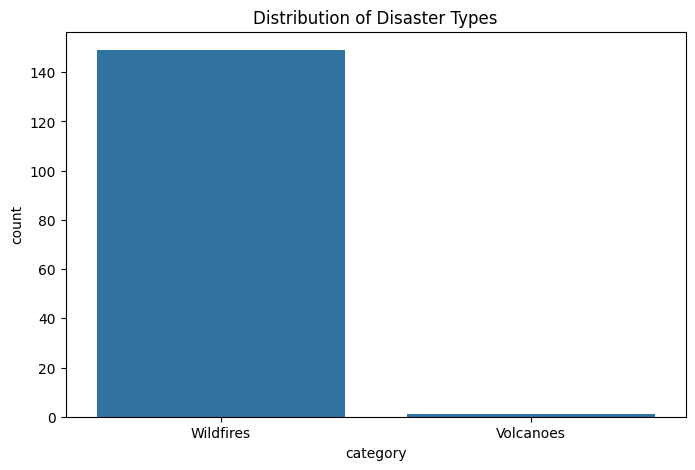

In [54]:
plt.figure(figsize=(8,5))
sns.countplot(data=combined_df, x="category")
plt.title("Distribution of Disaster Types")
plt.show()

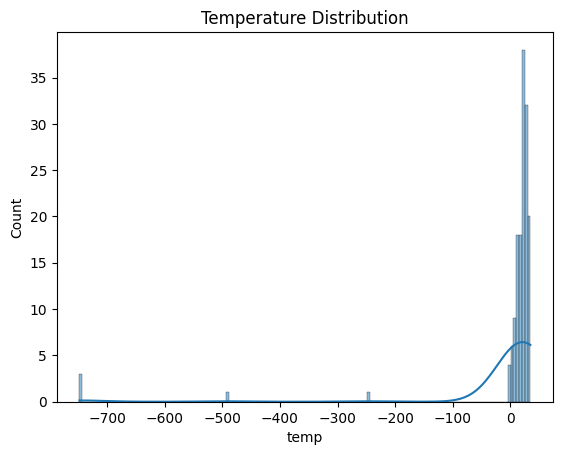

In [55]:
sns.histplot(combined_df["temp"], kde=True)
plt.title("Temperature Distribution")
plt.show()

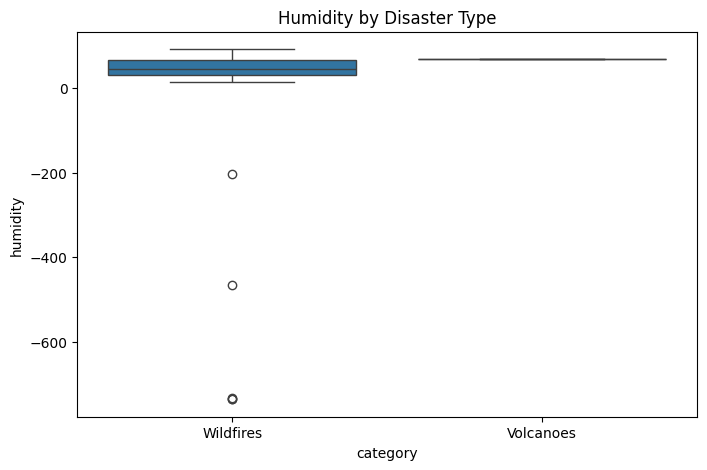

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(data=combined_df, x="category", y="humidity")
plt.title("Humidity by Disaster Type")
plt.show()

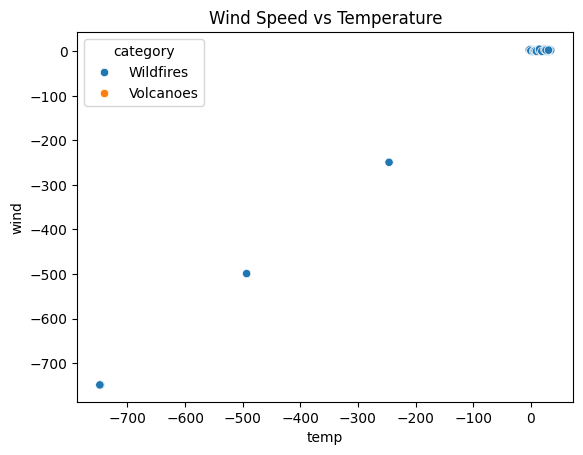

In [57]:
sns.scatterplot(data=combined_df,x="temp",y="wind",hue="category")
plt.title("Wind Speed vs Temperature")
plt.show()

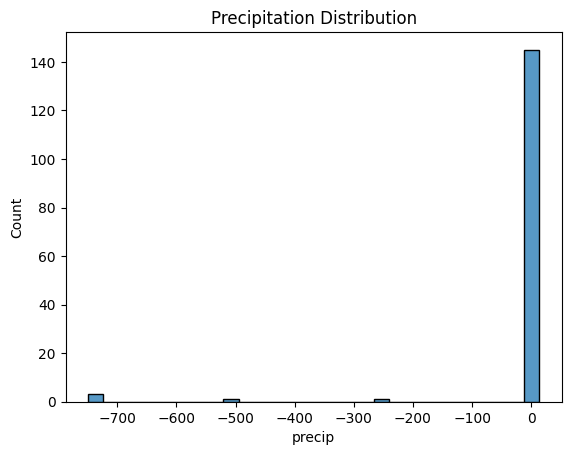

In [58]:
sns.histplot(combined_df["precip"], bins=30)
plt.title("Precipitation Distribution")
plt.show()


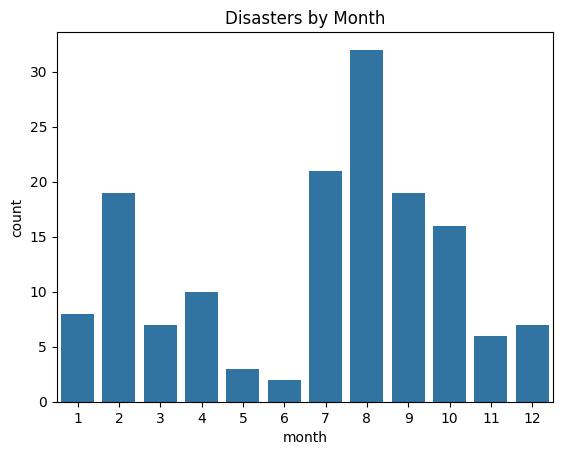

In [59]:
sns.countplot(x="month", data=combined_df)
plt.title("Disasters by Month")
plt.show()


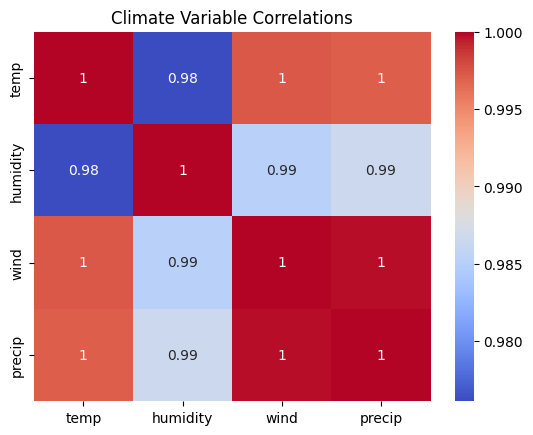

In [60]:
corr = combined_df[["temp","humidity","wind","precip"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Climate Variable Correlations")
plt.show()


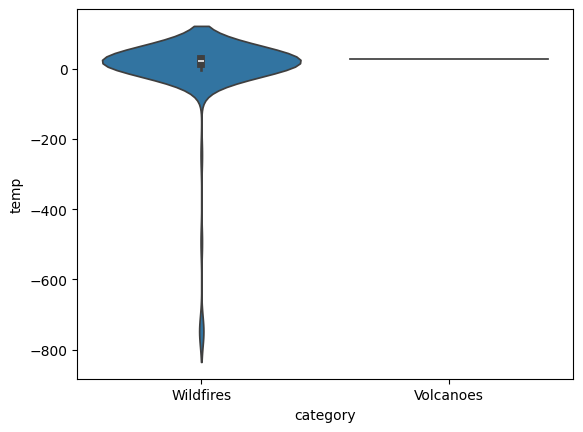

In [61]:
sns.violinplot(data=combined_df, x="category", y="temp")
plt.show()


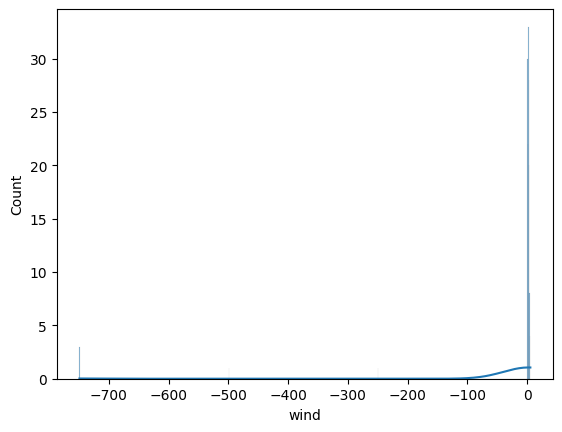

In [62]:
sns.histplot(combined_df["wind"], kde=True)
plt.show()


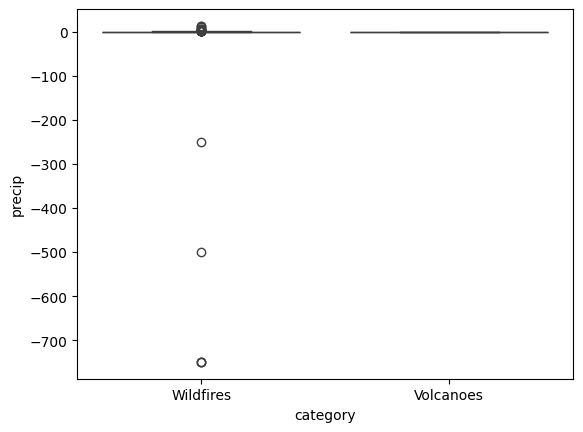

In [63]:
sns.boxplot(data=combined_df, x="category", y="precip")
plt.show()


In [64]:
len(df)

5000

**<h1>PCA**

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [66]:
pca_data = combined_df[["temp","humidity","wind","precip","latitude","longitude","month"]]

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

Explained Variance (2D): [0.59182147 0.25963119]
Total Variance: 0.8514526570360182


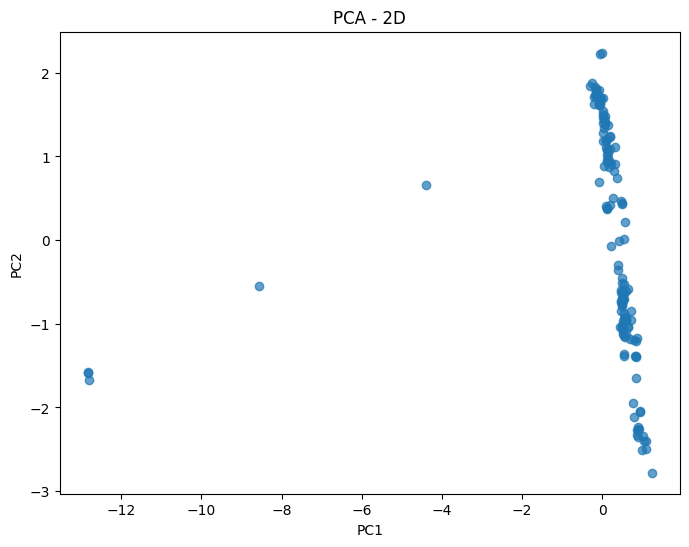

In [67]:
# PCA with 2 Components

pca_2 = PCA(n_components=2)
pca2_result = pca_2.fit_transform(scaled_data)

print("Explained Variance (2D):", pca_2.explained_variance_ratio_)
print("Total Variance:", sum(pca_2.explained_variance_ratio_))

# Plot 2D
plt.figure(figsize=(8,6))
plt.scatter(pca2_result[:,0], pca2_result[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D")
plt.show()

Explained Variance (3D): [0.59182147 0.25963119 0.08882318]
Total Variance: 0.9402758361982799


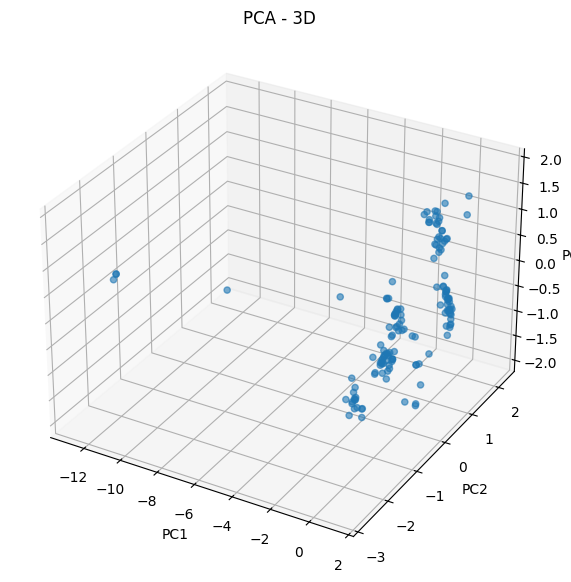

In [68]:
# PCA with 3 Components

pca_3 = PCA(n_components=3)
pca3_result = pca_3.fit_transform(scaled_data)

print("Explained Variance (3D):", pca_3.explained_variance_ratio_)
print("Total Variance:", sum(pca_3.explained_variance_ratio_))

# Plot 3D
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca3_result[:,0],
    pca3_result[:,1],
    pca3_result[:,2],
    alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA - 3D")
plt.show()

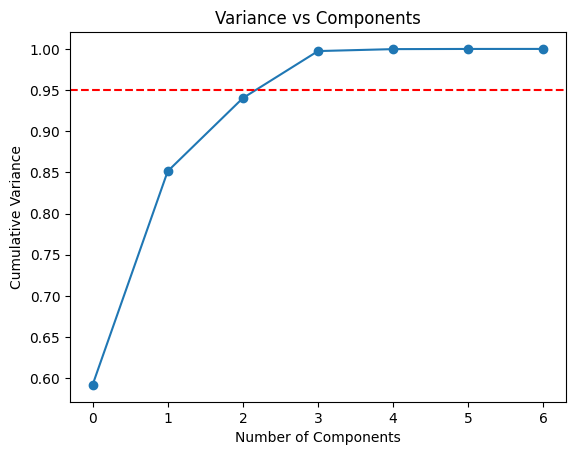

In [69]:
# Find Components for 95% Variance

pca_full = PCA()
pca_full.fit(scaled_data)

cumulative = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(cumulative, marker="o")
plt.axhline(0.95, color='r', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Variance vs Components")
plt.show()

In [70]:
# Number of components for 95%
components_95 = np.argmax(cumulative >= 0.95) + 1
print("Components for 95% Variance:", components_95)


Components for 95% Variance: 4


In [71]:
# Eigenvalues
print("Top 3 Eigenvalues:")
print(pca_full.explained_variance_[:3])

Top 3 Eigenvalues:
[4.17055397 1.82961576 0.62593516]


#**Clustering Analysis**

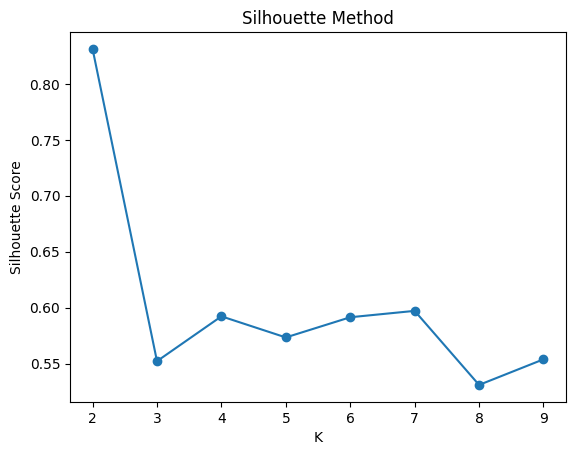

In [72]:
# Use PCA 3D data for clustering
X = pca3_result


# Silhouette Method (KMeans)

sil_scores = []
K_range = range(2,10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

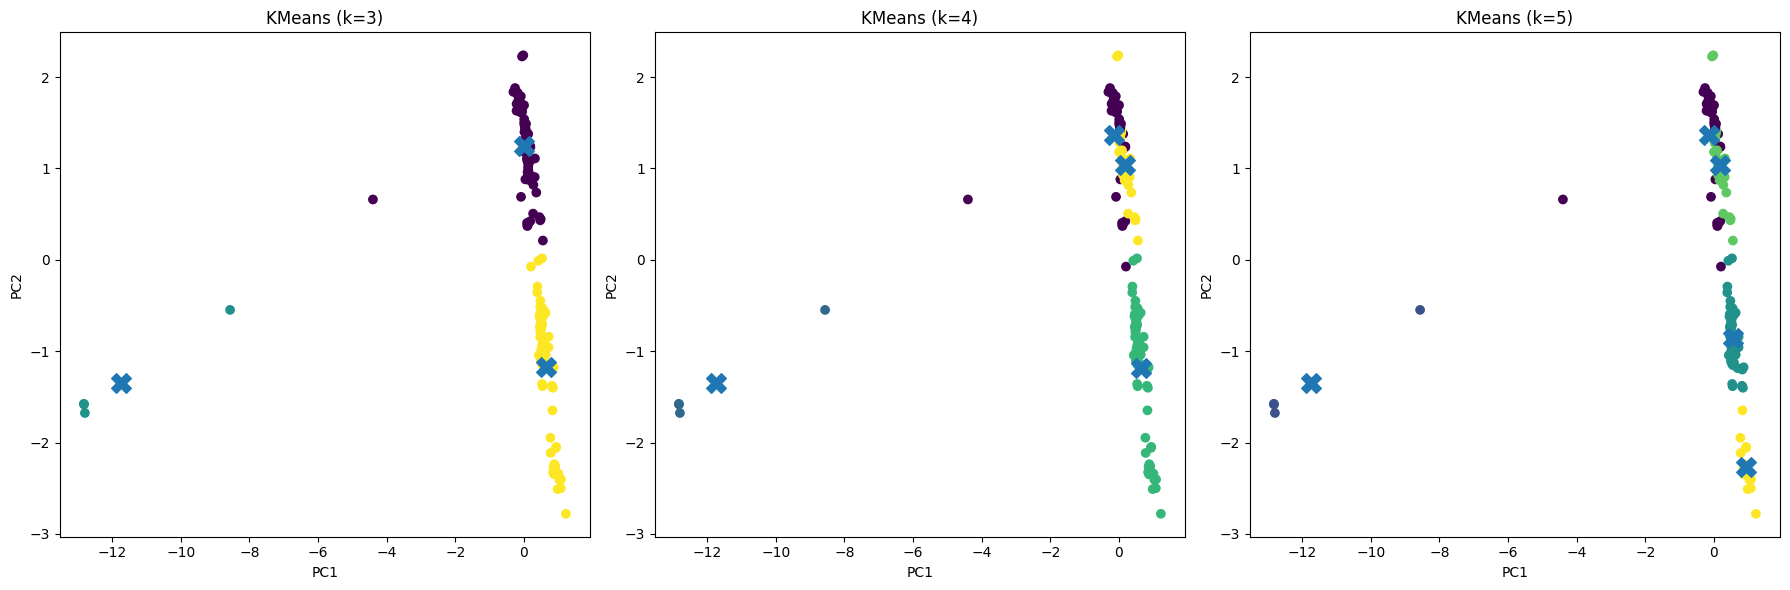

In [73]:
# KMeans with 3 values

k_values = [3, 4, 5]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_
    axes[i].scatter(X[:, 0], X[:, 1], c=labels)
    axes[i].scatter(
        centers[:, 0],
        centers[:, 1],
        s=200,
        marker='X')
    axes[i].set_title(f"KMeans (k={k})")
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")
plt.tight_layout()
plt.show()

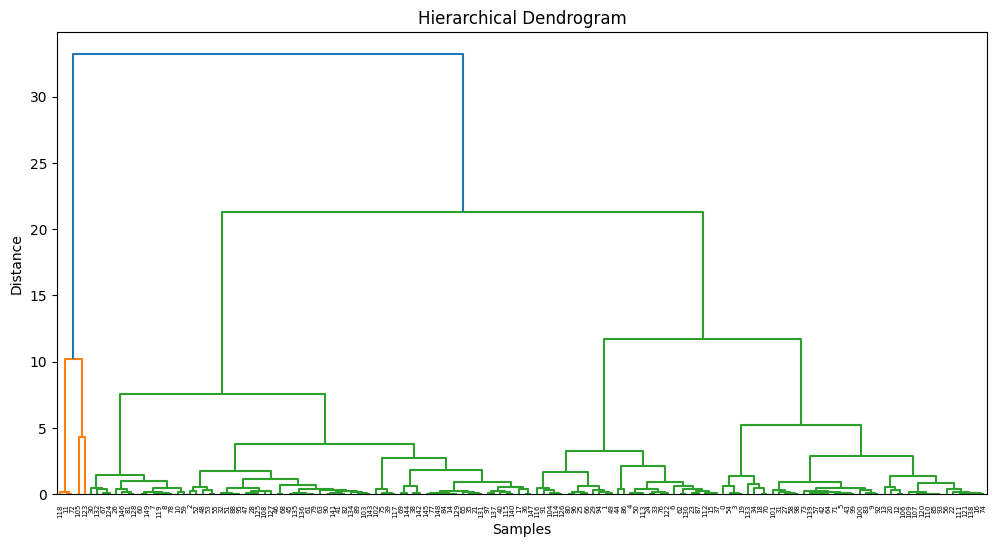

In [74]:
# Hierarchical Clustering

linked = linkage(X, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

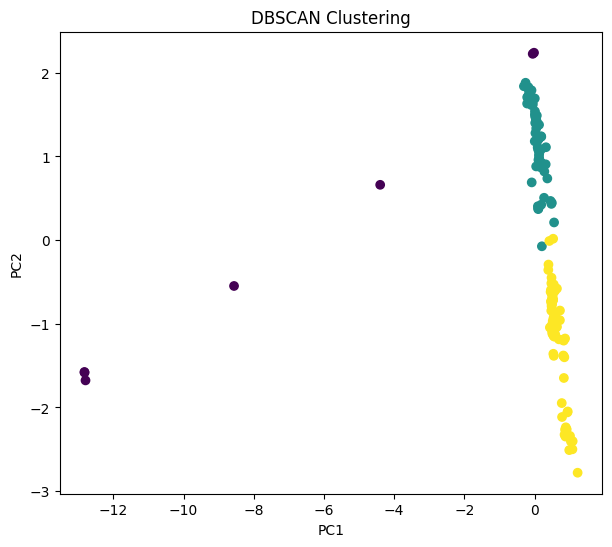

Unique DBSCAN Labels: [-1  0  1]


In [75]:
# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X)

plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], c=db_labels)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Unique DBSCAN Labels:", np.unique(db_labels))

#**Association Rule Mining**

In [80]:
from mlxtend.frequent_patterns import apriori, association_rules


# Discretize Numerical Data
arm_df = combined_df[["temp","humidity","wind","precip"]].copy()

# Convert to categories
arm_df["temp_cat"] = pd.qcut(arm_df["temp"], 3, labels=["Low","Medium","High"])
arm_df["humidity_cat"] = pd.qcut(arm_df["humidity"], 3, labels=["Low","Medium","High"])
arm_df["wind_cat"] = pd.qcut(arm_df["wind"], 3, labels=["Low","Medium","High"])
arm_df["precip_cat"] = pd.qcut(arm_df["precip"], 3, labels=["Low","Medium","High"])
arm_df = arm_df[[
    "temp_cat",
    "humidity_cat",
    "wind_cat",
    "precip_cat"]]

arm_df.head()

,temp_cat,humidity_cat,wind_cat,precip_cat
0,High,Medium,Medium,Low
1,Low,Medium,High,Low
2,Medium,Medium,High,Medium
3,Low,Medium,High,High
4,Medium,Medium,Low,Low


In [81]:
# one-hot encoding

encoded_df = pd.get_dummies(arm_df)
encoded_df.head()

,temp_cat_Low,temp_cat_Medium,temp_cat_High,humidity_cat_Low,humidity_cat_Medium,humidity_cat_High,wind_cat_Low,wind_cat_Medium,wind_cat_High,precip_cat_Low,precip_cat_Medium,precip_cat_High
0,False,False,True,False,True,False,False,True,False,True,False,False
1,True,False,False,False,True,False,False,False,True,True,False,False
2,False,True,False,False,True,False,False,False,True,False,True,False
3,True,False,False,False,True,False,False,False,True,False,False,True
4,False,True,False,False,True,False,True,False,False,True,False,False


In [82]:
# apriori algorithm

frequent_items = apriori(encoded_df, min_support=0.05, use_colnames=True)
frequent_items.sort_values("support", ascending=False).head(10)

,support,itemsets
9,0.386667,(precip_cat_Low)
0,0.333333,(temp_cat_Low)
1,0.333333,(temp_cat_Medium)
2,0.333333,(temp_cat_High)
4,0.333333,(humidity_cat_Medium)
3,0.333333,(humidity_cat_Low)
5,0.333333,(humidity_cat_High)
6,0.333333,(wind_cat_Low)
7,0.333333,(wind_cat_Medium)
8,0.333333,(wind_cat_High)


Generating rules

In [83]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1.0)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(humidity_cat_High),(temp_cat_Low),0.333333,0.333333,0.200000,0.600000,1.800000,1.0,0.088889,1.666667,0.666667,0.428571,0.400000,0.600000
1,(temp_cat_Low),(humidity_cat_High),0.333333,0.333333,0.200000,0.600000,1.800000,1.0,0.088889,1.666667,0.666667,0.428571,0.400000,0.600000
2,(wind_cat_Low),(temp_cat_Low),0.333333,0.333333,0.186667,0.560000,1.680000,1.0,0.075556,1.515152,0.607143,0.388889,0.340000,0.560000
3,(temp_cat_Low),(wind_cat_Low),0.333333,0.333333,0.186667,0.560000,1.680000,1.0,0.075556,1.515152,0.607143,0.388889,0.340000,0.560000
4,(precip_cat_Medium),(temp_cat_Low),0.280000,0.333333,0.100000,0.357143,1.071429,1.0,0.006667,1.037037,0.092593,0.194805,0.035714,0.328571


**Top 15 Rules**


In [84]:
# support

rules.sort_values("support", ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
34,(humidity_cat_Low),(precip_cat_Low),0.333333,0.386667,0.206667,0.620000,1.603448,1.0,0.077778,1.614035,0.564516,0.402597,0.380435,0.577241
35,(precip_cat_Low),(humidity_cat_Low),0.386667,0.333333,0.206667,0.534483,1.603448,1.0,0.077778,1.432099,0.613604,0.402597,0.301724,0.577241
0,(humidity_cat_High),(temp_cat_Low),0.333333,0.333333,0.200000,0.600000,1.800000,1.0,0.088889,1.666667,0.666667,0.428571,0.400000,0.600000
1,(temp_cat_Low),(humidity_cat_High),0.333333,0.333333,0.200000,0.600000,1.800000,1.0,0.088889,1.666667,0.666667,0.428571,0.400000,0.600000
2,(wind_cat_Low),(temp_cat_Low),0.333333,0.333333,0.186667,0.560000,1.680000,1.0,0.075556,1.515152,0.607143,0.388889,0.340000,0.560000
3,(temp_cat_Low),(wind_cat_Low),0.333333,0.333333,0.186667,0.560000,1.680000,1.0,0.075556,1.515152,0.607143,0.388889,0.340000,0.560000
46,(humidity_cat_High),(precip_cat_High),0.333333,0.333333,0.186667,0.560000,1.680000,1.0,0.075556,1.515152,0.607143,0.388889,0.340000,0.560000
47,(precip_cat_High),(humidity_cat_High),0.333333,0.333333,0.186667,0.560000,1.680000,1.0,0.075556,1.515152,0.607143,0.388889,0.340000,0.560000
18,(humidity_cat_Low),(temp_cat_High),0.333333,0.333333,0.173333,0.520000,1.560000,1.0,0.062222,1.388889,0.538462,0.351351,0.280000,0.520000
19,(temp_cat_High),(humidity_cat_Low),0.333333,0.333333,0.173333,0.520000,1.560000,1.0,0.062222,1.388889,0.538462,0.351351,0.280000,0.520000


In [85]:
# confidence

rules.sort_values("confidence", ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
218,"(precip_cat_Medium, wind_cat_Medium, temp_cat_...",(humidity_cat_Low),0.053333,0.333333,0.053333,1.000000,3.000000,1.0,0.035556,inf,0.704225,0.160000,1.000000,0.580000
204,"(precip_cat_High, wind_cat_Low, temp_cat_Low)",(humidity_cat_High),0.086667,0.333333,0.080000,0.923077,2.769231,1.0,0.051111,8.666667,0.699513,0.235294,0.884615,0.581538
172,"(precip_cat_Medium, humidity_cat_Low)",(wind_cat_Medium),0.086667,0.333333,0.073333,0.846154,2.538462,1.0,0.044444,4.333333,0.663570,0.211538,0.769231,0.533077
166,"(humidity_cat_Low, wind_cat_Low)",(precip_cat_Low),0.080000,0.386667,0.066667,0.833333,2.155172,1.0,0.035733,3.680000,0.582609,0.166667,0.728261,0.502874
68,"(precip_cat_High, temp_cat_Low)",(humidity_cat_High),0.140000,0.333333,0.113333,0.809524,2.428571,1.0,0.066667,3.500000,0.683995,0.314815,0.714286,0.574762
217,"(precip_cat_Medium, humidity_cat_Low, temp_cat...",(wind_cat_Medium),0.066667,0.333333,0.053333,0.800000,2.400000,1.0,0.031111,3.333333,0.625000,0.153846,0.700000,0.480000
142,"(precip_cat_Medium, humidity_cat_Low)",(temp_cat_High),0.086667,0.333333,0.066667,0.769231,2.307692,1.0,0.037778,2.888889,0.620438,0.188679,0.653846,0.484615
54,"(humidity_cat_High, wind_cat_Low)",(temp_cat_Low),0.173333,0.333333,0.133333,0.769231,2.307692,1.0,0.075556,2.888889,0.685484,0.357143,0.653846,0.584615
180,"(humidity_cat_Low, wind_cat_High)",(precip_cat_Low),0.113333,0.386667,0.086667,0.764706,1.977688,1.0,0.042844,2.606667,0.557548,0.209677,0.616368,0.494422
202,"(humidity_cat_High, wind_cat_Low, precip_cat_H...",(temp_cat_Low),0.106667,0.333333,0.080000,0.750000,2.250000,1.0,0.044444,2.666667,0.621891,0.222222,0.625000,0.495000


In [86]:
# lift

rules.sort_values("lift", ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
220,"(precip_cat_Medium, humidity_cat_Low)","(wind_cat_Medium, temp_cat_High)",0.086667,0.140000,0.053333,0.615385,4.395604,1.0,0.041200,2.236000,0.845803,0.307692,0.552773,0.498168
225,"(wind_cat_Medium, temp_cat_High)","(precip_cat_Medium, humidity_cat_Low)",0.140000,0.086667,0.053333,0.380952,4.395604,1.0,0.041200,1.475385,0.898256,0.307692,0.322211,0.498168
222,"(precip_cat_Medium, temp_cat_High)","(humidity_cat_Low, wind_cat_Medium)",0.100000,0.140000,0.053333,0.533333,3.809524,1.0,0.039333,1.842857,0.819444,0.285714,0.457364,0.457143
223,"(humidity_cat_Low, wind_cat_Medium)","(precip_cat_Medium, temp_cat_High)",0.140000,0.100000,0.053333,0.380952,3.809524,1.0,0.039333,1.453846,0.857558,0.285714,0.312169,0.457143
211,"(precip_cat_High, temp_cat_Low)","(humidity_cat_High, wind_cat_Low)",0.140000,0.173333,0.080000,0.571429,3.296703,1.0,0.055733,1.928889,0.810078,0.342857,0.481567,0.516484
206,"(humidity_cat_High, wind_cat_Low)","(precip_cat_High, temp_cat_Low)",0.173333,0.140000,0.080000,0.461538,3.296703,1.0,0.055733,1.597143,0.842742,0.342857,0.373882,0.516484
227,(humidity_cat_Low),"(precip_cat_Medium, wind_cat_Medium, temp_cat_...",0.333333,0.053333,0.053333,0.160000,3.000000,1.0,0.035556,1.126984,1.000000,0.160000,0.112676,0.580000
218,"(precip_cat_Medium, wind_cat_Medium, temp_cat_...",(humidity_cat_Low),0.053333,0.333333,0.053333,1.000000,3.000000,1.0,0.035556,inf,0.704225,0.160000,1.000000,0.580000
213,(humidity_cat_High),"(precip_cat_High, wind_cat_Low, temp_cat_Low)",0.333333,0.086667,0.080000,0.240000,2.769231,1.0,0.051111,1.201754,0.958333,0.235294,0.167883,0.581538
204,"(precip_cat_High, wind_cat_Low, temp_cat_Low)",(humidity_cat_High),0.086667,0.333333,0.080000,0.923077,2.769231,1.0,0.051111,8.666667,0.699513,0.235294,0.884615,0.581538


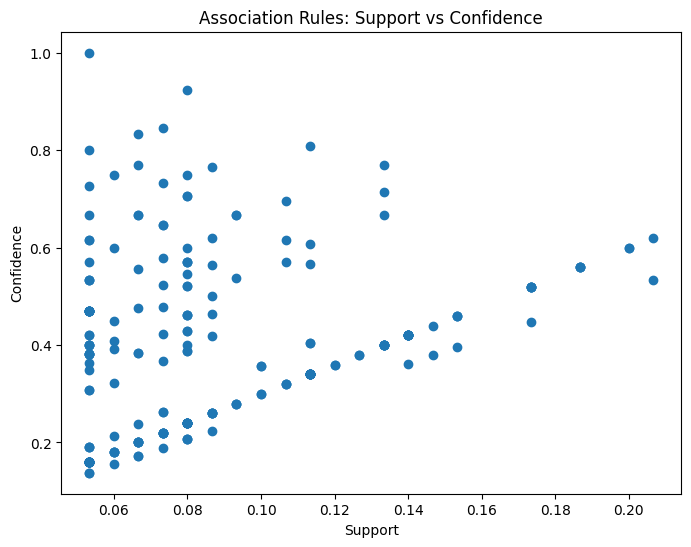

In [89]:
plt.figure(figsize=(8,6))

plt.scatter(
    rules["support"],
    rules["confidence"])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs Confidence")

plt.show()

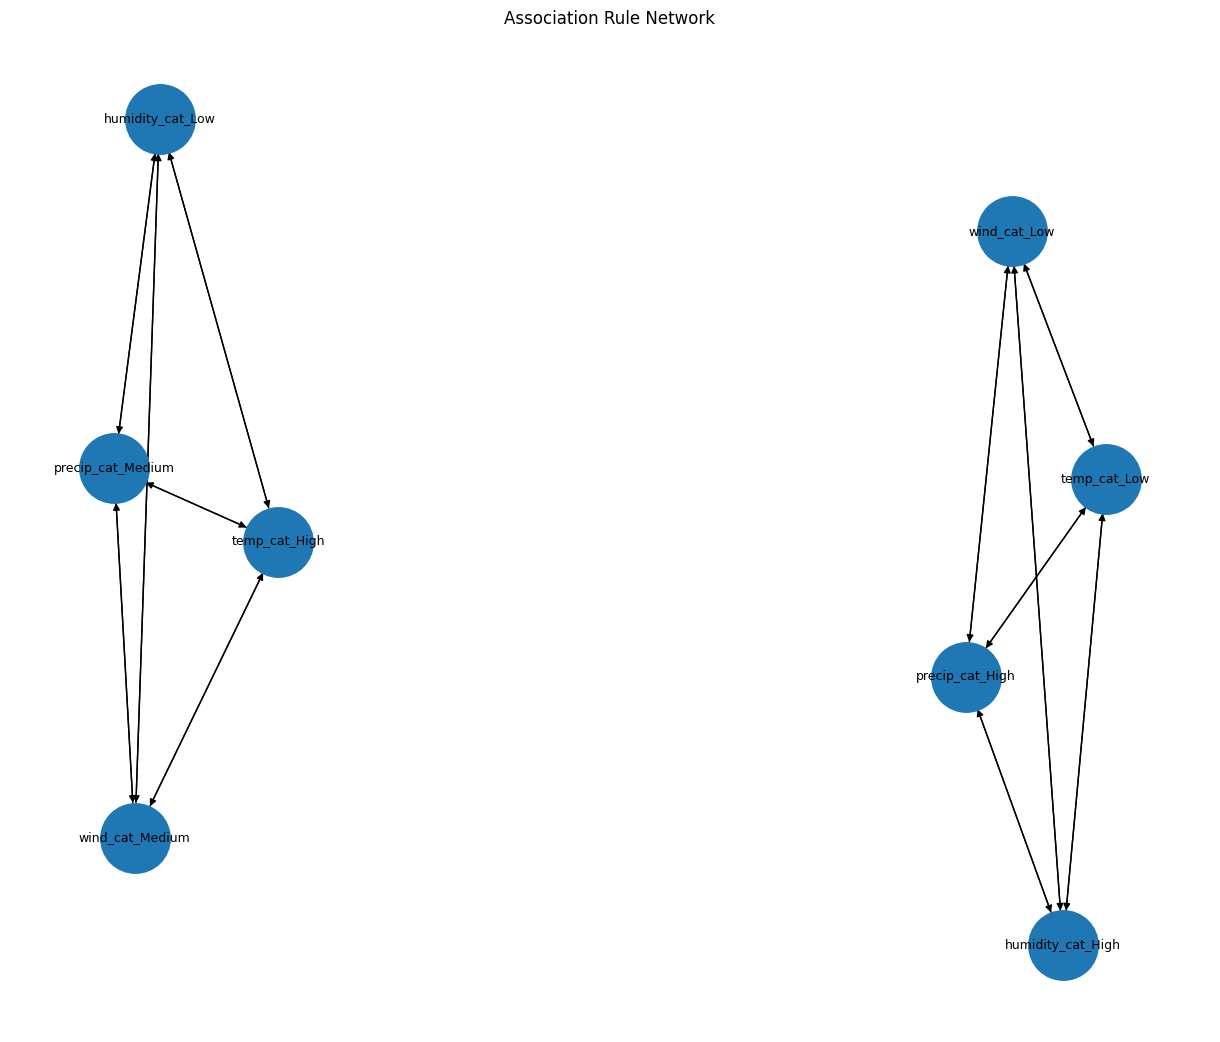

In [90]:
import networkx as nx

plt.figure(figsize=(12,10))
G = nx.DiGraph()
top_rules = rules.sort_values("lift", ascending=False).head(15)
for _, row in top_rules.iterrows():

    for ant in row["antecedents"]:
        for con in row["consequents"]:
            G.add_edge(ant, con, weight=row["lift"])

pos = nx.spring_layout(G, k=1)
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    font_size=9)

plt.title("Association Rule Network")
plt.show()